<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/%D0%A1%D0%BF%D0%BE%D1%80%D1%82%D1%81%D0%BC%D0%B5%D0%BD%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# Загрузка данных
athletes = pd.read_csv("https://raw.githubusercontent.com/trisha00001/Data_Preprocessing/main/athletes.csv")

# Просмотр структуры данных
print("Первые 5 строк:")
print(athletes.head())
print(f"\nРазмер данных: {athletes.shape}")
print(f"\nТипы данных:\n{athletes.dtypes}")

Первые 5 строк:
          id            name nationality     sex       dob  height  weight  \
0  736041664  A Jesus Garcia         ESP    male  10/17/69    1.72    64.0   
1  532037425      A Lam Shin         KOR  female   9/23/86    1.68    56.0   
2  435962603     Aaron Brown         CAN    male   5/27/92    1.98    79.0   
3  521041435      Aaron Cook         MDA    male    1/2/91    1.83    80.0   
4   33922579      Aaron Gate         NZL    male  11/26/90    1.81    71.0   

       sport  gold  silver  bronze  
0  athletics     0       0       0  
1    fencing     0       0       0  
2  athletics     0       0       1  
3  taekwondo     0       0       0  
4    cycling     0       0       0  

Размер данных: (11538, 11)

Типы данных:
id               int64
name            object
nationality     object
sex             object
dob             object
height         float64
weight         float64
sport           object
gold             int64
silver           int64
bronze           int6

In [4]:
import pandas as pd

# Загрузка данных (перевыполнение для исправления NameError)
athletes = pd.read_csv("https://raw.githubusercontent.com/trisha00001/Data_Preprocessing/main/athletes.csv")


1. **Проверка: В среднем рост мужчин выше роста женщин (t-test)**

In [5]:
# Очистка данных: убираем пропуски в росте и поле
df_clean = athletes.dropna(subset=['height', 'sex'])

# Разделение по полу
men_height = df_clean[df_clean['sex'] == 'male']['height']
women_height = df_clean[df_clean['sex'] == 'female']['height']

print(f"\n=== Анализ роста по полу ===")
print(f"Мужчины: n={len(men_height)}, средний рост={men_height.mean():.2f} см, std={men_height.std():.2f}")
print(f"Женщины: n={len(women_height)}, средний рост={women_height.mean():.2f} см, std={women_height.std():.2f}")

# Двухвыборочный t-критерий Стьюдента (непарный)
t_stat, p_value = stats.ttest_ind(men_height, women_height, alternative='greater')

print(f"\nT-test (односторонний, H1: men > women):")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")

# Вывод
alpha = 0.05
if p_value < alpha:
    print(f"\n✅ Вывод: при α={alpha} отвергаем H0. Рост мужчин статистически значимо выше роста женщин.")
else:
    print(f"\n❌ Вывод: при α={alpha} нет оснований отвергнуть H0. Разница в росте не значима.")


=== Анализ роста по полу ===
Мужчины: n=6142, средний рост=1.82 см, std=0.10
Женщины: n=5066, средний рост=1.70 см, std=0.09

T-test (односторонний, H1: men > women):
t-statistic = 66.8936
p-value = 0.000000

✅ Вывод: при α=0.05 отвергаем H0. Рост мужчин статистически значимо выше роста женщин.


**2. Проверка: Различается ли рост мужчин в футболе, баскетболе и волейболе (ANOVA)**

In [6]:
# Фильтруем: только мужчины и нужные виды спорта
male_team_sports = df_clean[
    (df_clean['sex'] == 'male') &
    (df_clean['sport'].isin(['football', 'basketball', 'volleyball']))
].dropna(subset=['height'])

print(f"\n=== Анализ роста мужчин в командных видах спорта ===")
print(f"Выборка: {len(male_team_sports)} записей")

# Группировка по виду спорта
football_height = male_team_sports[male_team_sports['sport'] == 'football']['height']
basketball_height = male_team_sports[male_team_sports['sport'] == 'basketball']['height']
volleyball_height = male_team_sports[male_team_sports['sport'] == 'volleyball']['height']

print(f"\nСтатистика по видам спорта:")
print(f"🏈 Football:    n={len(football_height):3d}, mean={football_height.mean():.2f} см, std={football_height.std():.2f}")
print(f"🏀 Basketball: n={len(basketball_height):3d}, mean={basketball_height.mean():.2f} см, std={basketball_height.std():.2f}")
print(f"🏐 Volleyball: n={len(volleyball_height):3d}, mean={volleyball_height.mean():.2f} см, std={volleyball_height.std():.2f}")

# Однофакторный дисперсионный анализ (ANOVA)
f_stat, p_value_anova = stats.f_oneway(football_height, basketball_height, volleyball_height)

print(f"\nANOVA (H0: все средние равны):")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {p_value_anova:.6f}")

# Вывод
alpha = 0.05
if p_value_anova < alpha:
    print(f"\n✅ Вывод: при α={alpha} отвергаем H0. Рост мужчин в этих видах спорта статистически значимо различается.")

    # Пост-хок анализ (Tukey HSD) для определения, где именно различия
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    # Подготовка данных для Tukey
    data_tukey = male_team_sports[['height', 'sport']].copy()
    tukey = pairwise_tukeyhsd(endog=data_tukey['height'],
                              groups=data_tukey['sport'],
                              alpha=0.05)
    print(f"\n📊 Пост-хок анализ (Tukey HSD):")
    print(tukey)
else:
    print(f"\n❌ Вывод: при α={alpha} нет оснований отвергнуть H0. Средний рост мужчин в футболе, баскетболе и волейболе не различается статистически значимо.")


=== Анализ роста мужчин в командных видах спорта ===
Выборка: 675 записей

Статистика по видам спорта:
🏈 Football:    n=339, mean=1.79 см, std=0.07
🏀 Basketball: n=144, mean=2.00 см, std=0.08
🏐 Volleyball: n=192, mean=1.96 см, std=0.08

ANOVA (H0: все средние равны):
F-statistic = 521.8194
p-value = 0.000000

✅ Вывод: при α=0.05 отвергаем H0. Рост мужчин в этих видах спорта статистически значимо различается.

📊 Пост-хок анализ (Tukey HSD):
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj  lower   upper  reject
-----------------------------------------------------------
basketball   football  -0.2099   0.0 -0.2276 -0.1921   True
basketball volleyball  -0.0396   0.0 -0.0593 -0.0199   True
  football volleyball   0.1703   0.0  0.1541  0.1864   True
-----------------------------------------------------------


**3. Визуализация результатов**

/tmp/ipykernel_5081/3656942487.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='sex', y='height', ax=axes[0], palette='Set2')
/tmp/ipykernel_5081/3656942487.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sports_data, x='sport', y='height', ax=axes[1], palette='Set1')



📈 Графики сохранены в файл 'athletes_analysis.png'


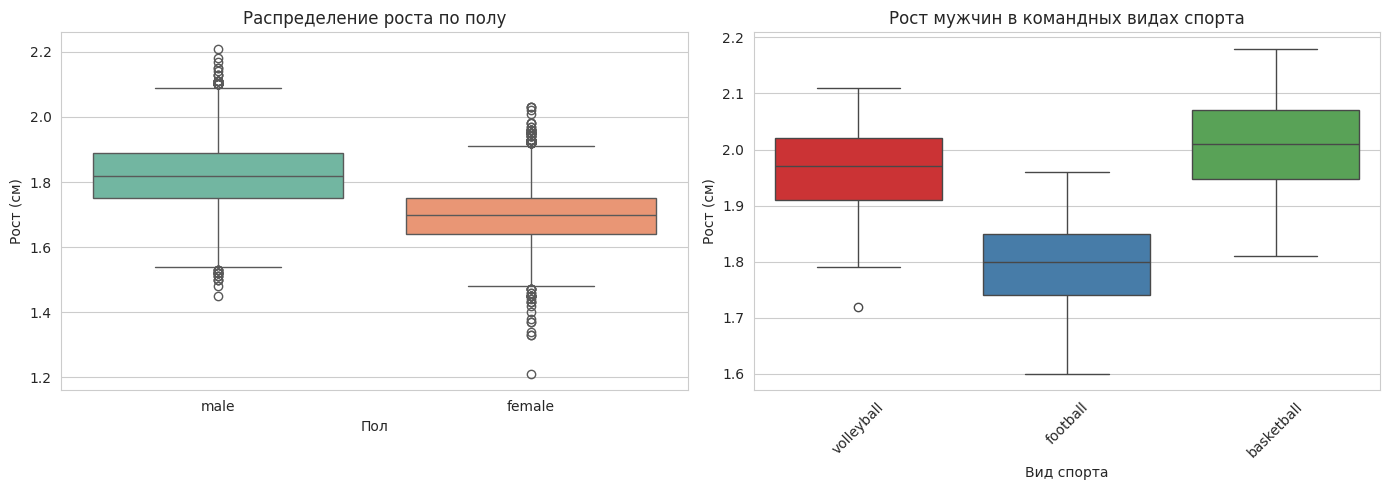

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение роста по полу
sns.boxplot(data=df_clean, x='sex', y='height', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение роста по полу')
axes[0].set_ylabel('Рост (см)')
axes[0].set_xlabel('Пол')

# График 2: Рост мужчин в командных видах спорта
sports_data = male_team_sports[male_team_sports['sport'].isin(['football', 'basketball', 'volleyball'])]
sns.boxplot(data=sports_data, x='sport', y='height', ax=axes[1], palette='Set1')
axes[1].set_title('Рост мужчин в командных видах спорта')
axes[1].set_ylabel('Рост (см)')
axes[1].set_xlabel('Вид спорта')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('athletes_analysis.png', dpi=300, bbox_inches='tight')
print("\n📈 Графики сохранены в файл 'athletes_analysis.png'")
plt.show()

**Краткий отчёт по результатам**

In [9]:
print("\n" + "="*60)
print("ИТОГОВЫЙ ОТЧЁТ")
print("="*60)

# 1. T-test результат
t_stat, p_t = stats.ttest_ind(men_height, women_height, alternative='greater')
print(f"\n1️⃣ Сравнение роста мужчин и женщин:")
print(f"   • Средний рост мужчин: {men_height.mean():.2f} см")
print(f"   • Средний рост женщин: {women_height.mean():.2f} см")
print(f"   • Разница: {men_height.mean() - women_height.mean():.2f} см")
print(f"   • p-value (t-test): {p_t:.6f}")
print(f"   • {'✅ Рост мужчин значимо выше' if p_t < 0.05 else '❌ Разница не значима'}")

# 2. ANOVA результат
f_stat, p_anova = stats.f_oneway(football_height, basketball_height, volleyball_height)
print(f"\n2️⃣ Сравнение роста мужчин в командных видах спорта:")
print(f"   • Football:    {football_height.mean():.2f} см")
print(f"   • Basketball:  {basketball_height.mean():.2f} см")
print(f"   • Volleyball:  {volleyball_height.mean():.2f} см")
print(f"   • p-value (ANOVA): {p_anova:.6f}")
print(f"   • {'✅ Рост различается между видами спорта' if p_anova < 0.05 else '❌ Рост статистически одинаков'}")

print("\n" + "="*60)


ИТОГОВЫЙ ОТЧЁТ

1️⃣ Сравнение роста мужчин и женщин:
   • Средний рост мужчин: 1.82 см
   • Средний рост женщин: 1.70 см
   • Разница: 0.12 см
   • p-value (t-test): 0.000000
   • ✅ Рост мужчин значимо выше

2️⃣ Сравнение роста мужчин в командных видах спорта:
   • Football:    1.79 см
   • Basketball:  2.00 см
   • Volleyball:  1.96 см
   • p-value (ANOVA): 0.000000
   • ✅ Рост различается между видами спорта

